# Imports dependencies

In [2]:
import sys
sys.path.append('..')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.data_loader import DataLoader
loader = DataLoader("../dataset/ml-1m/")
ratings = loader.load_rating()
movies = loader.load_movies()
users = loader.load_users()
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")
# print("Ratings:", ratings.shape)
# print(ratings.head())

# Global Sparsity Metrics

In [7]:
n_users = ratings["user_id"].nunique()
n_movies = ratings["movie_id"].nunique()
n_ratings = ratings["rating"].nunique()
density = n_ratings / (n_users * n_movies)

print(f"Matrix dimensions: {n_users:,} users x {n_movies:,} movies")
print(f"Filled cells: {n_ratings:,}")
print(f"Empty cells: {n_users * n_movies - n_ratings:,}")
print(f"Density: {density:.4%}")
# Saving exact number for paper
with open('../results/sparsity_metrics.txt','w') as f:
    f.write(f"users={n_users}\nmovies={n_movies}\nratings={n_ratings}\ndensity={density:.6f}\n")

Matrix dimensions: 6,040 users x 3,706 movies
Filled cells: 5
Empty cells: 22,384,235
Density: 0.0000%


# Sparsity HeatMap

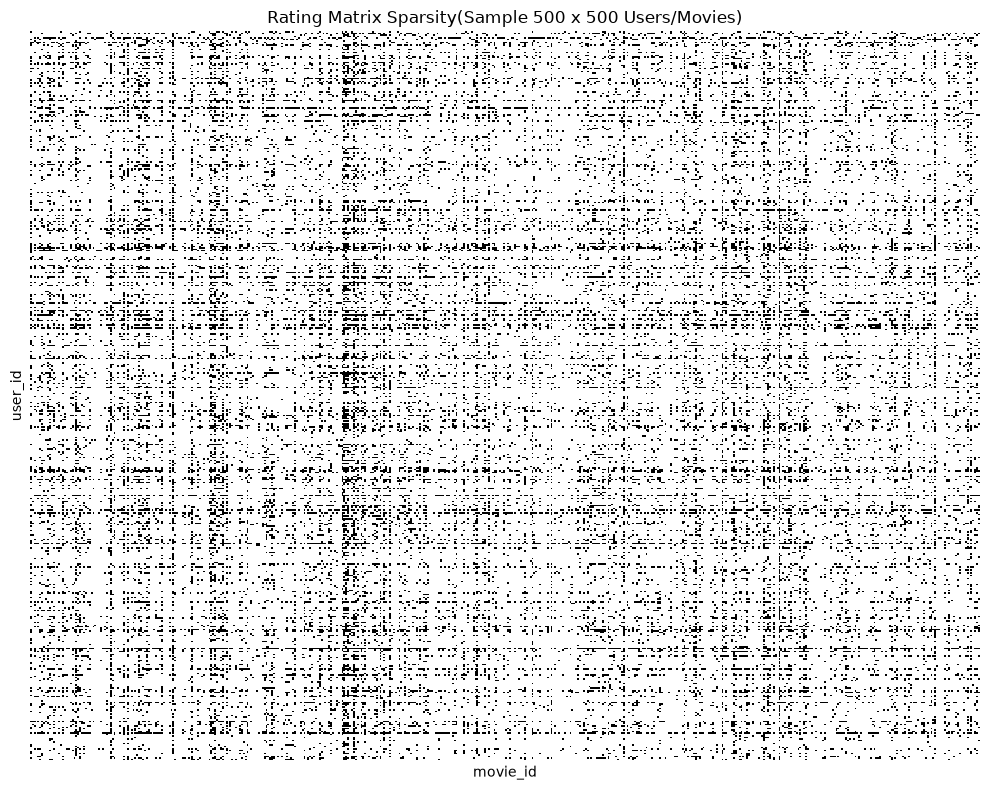

In [10]:
# pivoting a sample (full matrix is too big for heatmap)
sample_users = ratings["user_id"].unique()[:500]
sample_items = ratings["movie_id"].unique()[:500]

pivot_sample = ratings[
    (ratings["user_id"].isin(sample_users)) & 
    (ratings["movie_id"].isin(sample_items))
].pivot_table(index="user_id", columns="movie_id", values="rating")

plt.figure(figsize=(10,8))
sns.heatmap(pivot_sample.notnull(), cmap="Greys", cbar=False, yticklabels=False, xticklabels=False)

plt.title("Rating Matrix Sparsity(Sample 500 x 500 Users/Movies)")
plt.tight_layout()
plt.savefig("../figures/fig_03_sparsity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()